# Karush-Kuhn-Tucker (KKT) Conditions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/DEV/L08/L08_kkt_conditions.ipynb)
### MECH 559 - Systems Optimization - L08

Companion notebook to the "Nonlinear programming" lecture. It works through the KKT conditions for problems with *inequality* constraints: the sign of the multipliers, complementary slackness, the geometric picture ($-\nabla f$ as a non-negative combination of active-constraint gradients), and two of the deck's own worked examples - one where a KKT point turns out to be a maximizer (Class Exercise 3, Q1), and one where the KKT conditions cannot even be solved because the point is not regular (Class Exercise 4, Q1).

## Learning objectives

By the end, students should be able to:

1. State the KKT conditions for $\min f(x)\ \text{s.t.}\ g(x)\le0,\ h(x)=0$ and verify them numerically at a candidate solution.
2. Explain, and see demonstrated, why $\mu\ge0$ is required at a regular minimizer but $\lambda$ (for equality constraints) is unrestricted in sign.
3. Recognize complementary slackness ($\mu^{\mathsf T}g=0$) as an active/inactive switch, and watch it operate as a problem's data changes continuously.
4. Combine the KKT conditions with the reduced-Hessian SOSC (from `L08_lagrangian_and_sosc.ipynb`) to confirm whether a KKT point is a minimizer or not.
5. See concretely what breaks down at a non-regular point: the KKT stationarity system can become unsolvable.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import null_space
from scipy.optimize import minimize

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"feasible": "#A8DADC", "boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49", "other": "#6C5B7B"}

print(f"NumPy {np.__version__}")

NumPy 2.5.0


---
## 1. A minimal inequality-constrained example

$$
\min_{x_1,x_2} f(x) = (x_1-3)^2+(x_2-2)^2
\quad\text{s.t.}\quad
g_1(x)=x_1+x_2-2\le0,\qquad g_2(x)=-x_1\le0,\qquad g_3(x)=-x_2\le0.
$$

The unconstrained minimizer of $f$ is $(3,2)$, which violates $g_1$ ($3+2=5>2$), so we expect $g_1$ to be active at the solution and $g_2,g_3$ to be inactive. Geometrically the constrained minimizer is the point on the line $x_1+x_2=2$ closest to $(3,2)$.

> **Predict:** using similar triangles / orthogonal projection, guess the constrained minimizer before running the next cell.

In [3]:
def f(x):
    return (x[0] - 3)**2 + (x[1] - 2)**2

def grad_f(x):
    return np.array([2 * (x[0] - 3), 2 * (x[1] - 2)])

def g(x):
    return np.array([x[0] + x[1] - 2, -x[0], -x[1]])

def grad_g(x):
    return np.array([[1.0, 1.0], [-1.0, 0.0], [0.0, -1.0]])

cons = [{"type": "ineq", "fun": lambda x: -g(x)}]  # scipy wants >= 0
res = minimize(f, x0=[0.0, 0.0], constraints=cons)
x_star = res.x
print("numerical solve: x* =", x_star, " f(x*) =", f(x_star))

x_star_closed = np.array([1.5, 0.5])
print("closed-form projection of (3,2) onto x1+x2=2: ", x_star_closed)
print("match?", np.allclose(x_star, x_star_closed, atol=1e-4))

numerical solve: x* = [1.49999999 0.50000001]  f(x*) = 4.500000000000028
closed-form projection of (3,2) onto x1+x2=2:  [1.5 0.5]
match? True


---
## 2. Verifying the KKT conditions by hand

Active set at $x^*$: only $g_1$ is active ($g_1(x^*)=0$); $g_2,g_3$ are strictly satisfied, so complementary slackness forces $\mu_2=\mu_3=0$. Stationarity then reduces to $\nabla f(x^*)+\mu_1\nabla g_1(x^*)=0$, one vector equation in one unknown $\mu_1$.

In [4]:
active = np.isclose(g(x_star), 0.0, atol=1e-6)
print("g(x*)  =", g(x_star))
print("active constraints:", active)

Ja = grad_g(x_star)[active]         # active-constraint gradients only
mu_active, *_ = np.linalg.lstsq(Ja.T, -grad_f(x_star), rcond=None)
resid = Ja.T @ mu_active + grad_f(x_star)
print("\nactive-set stationarity solve: mu (for active g's) =", mu_active)
print("residual of nabla f + Ja^T mu (should be ~0):", resid)
print("dual feasibility mu >= 0?", np.all(mu_active >= -1e-8))
print("primal feasibility g <= 0?", np.all(g(x_star) <= 1e-8))

mu_full = np.zeros(3)
mu_full[active] = mu_active
print("\ncomplementary slackness mu^T g =", mu_full @ g(x_star), " (should be ~0)")

g(x*)  = [-9.32587341e-15 -1.49999999e+00 -5.00000007e-01]
active constraints: [ True False False]

active-set stationarity solve: mu (for active g's) = [3.]
residual of nabla f + Ja^T mu (should be ~0): [-1.49011936e-08  1.49011918e-08]
dual feasibility mu >= 0? True
primal feasibility g <= 0? True

complementary slackness mu^T g = -2.7977620220554024e-14  (should be ~0)


---
## 3. Geometric picture: $-\nabla f$ as a non-negative combination of active gradients

The first KKT condition $\nabla f+\nabla g^{\mathsf T}\mu=0$ says $-\nabla f(x^*)=\mu_1\nabla g_1(x^*)$: at the optimum, the "downhill" direction of $f$ is exactly canceled by a *non-negative* combination of active-constraint gradients (this is the geometric content of $\mu\ge0$: if $\mu_1$ were forced negative, $-\nabla f$ would point *out* of the feasible cone, and $x^*$ could not be optimal).

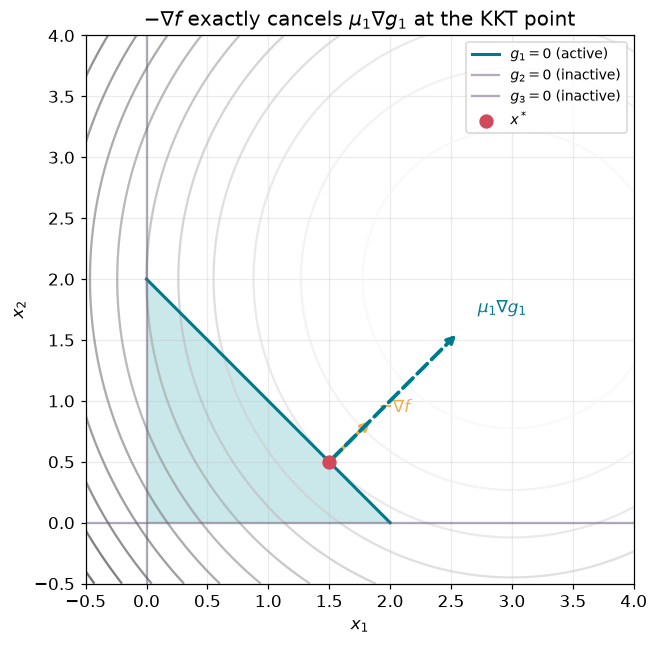

In [5]:
xx1, xx2 = np.meshgrid(np.linspace(-0.5, 4, 300), np.linspace(-0.5, 4, 300))
F = (xx1 - 3)**2 + (xx2 - 2)**2

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.contour(xx1, xx2, F, levels=15, cmap="Greys", alpha=0.6)
feasible = (xx1 + xx2 <= 2) & (xx1 >= 0) & (xx2 >= 0)
ax.contourf(xx1, xx2, feasible.astype(float), levels=[0.5, 1.5], colors=[COLORS["feasible"]], alpha=0.6)
ax.plot([0, 2], [2, 0], color=COLORS["boundary"], lw=2, label="$g_1=0$ (active)")
ax.axvline(0, color=COLORS["other"], lw=1.5, alpha=0.5, label="$g_2=0$ (inactive)")
ax.axhline(0, color=COLORS["other"], lw=1.5, alpha=0.5, label="$g_3=0$ (inactive)")

ax.scatter(*x_star, color=COLORS["optimum"], s=70, zorder=4, label="$x^*$")
scale = 0.5
neg_grad_f = -grad_f(x_star) / np.linalg.norm(grad_f(x_star))
mu1_g1 = mu_active[0] * grad_g(x_star)[0] / np.linalg.norm(grad_g(x_star)[0])
ax.annotate("", xy=x_star + scale * neg_grad_f, xytext=x_star,
            arrowprops=dict(arrowstyle="->", color=COLORS["accent"], lw=2.5))
ax.text(*(x_star + scale * neg_grad_f * 1.15), r"$-\nabla f$", color=COLORS["accent"])
ax.annotate("", xy=x_star + scale * mu1_g1, xytext=x_star,
            arrowprops=dict(arrowstyle="->", color=COLORS["boundary"], lw=2.5, linestyle="--"))
ax.text(*(x_star + scale * mu1_g1 * 1.15), r"$\mu_1\nabla g_1$", color=COLORS["boundary"])

ax.set(xlabel="$x_1$", ylabel="$x_2$", xlim=(-0.5, 4), ylim=(-0.5, 4),
       title=r"$-\nabla f$ exactly cancels $\mu_1 \nabla g_1$ at the KKT point")
ax.legend(loc="upper right", fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---
## 4. Watching complementary slackness switch on

We now move the target point from $(0.5,0.5)$ (already feasible, so $g_1$ should be **inactive**, $\mu_1=0$) to $(4,3)$ (far outside, so $g_1$ is active with a growing $\mu_1$), and watch $\mu_1$ and $g_1(x^*)$ trade off - one of them is always (numerically) zero, which is exactly complementary slackness $\mu_1 g_1=0$.

> **Predict:** at what target-point parameter do you expect the switch from inactive to active to happen?

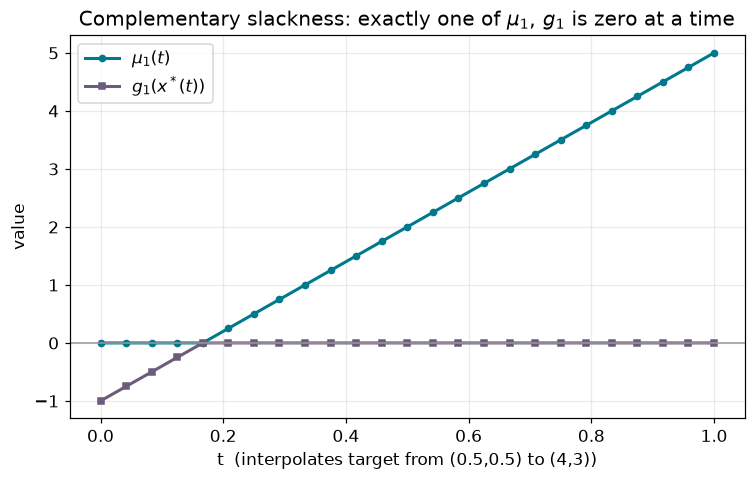

max |mu1 * g1| over the sweep (should be ~0): 6.417089082333239e-13


In [6]:
def solve_and_get_mu1(target):
    def f_t(x):
        return (x[0] - target[0])**2 + (x[1] - target[1])**2

    def grad_f_t(x):
        return np.array([2 * (x[0] - target[0]), 2 * (x[1] - target[1])])

    cons_t = [{"type": "ineq", "fun": lambda x: -g(x)}]
    res_t = minimize(f_t, x0=[0.5, 0.5], constraints=cons_t)
    x_t = res_t.x
    active_t = np.isclose(g(x_t), 0.0, atol=1e-6)
    if not active_t.any():
        return x_t, 0.0, g(x_t)[0]
    Ja_t = grad_g(x_t)[active_t]
    mu_t, *_ = np.linalg.lstsq(Ja_t.T, -grad_f_t(x_t), rcond=None)
    mu1 = mu_t[0] if active_t[0] else 0.0
    return x_t, mu1, g(x_t)[0]

ts = np.linspace(0.0, 1.0, 25)
mu1_vals, g1_vals = [], []
for t in ts:
    target = (0.5, 0.5) + t * (np.array([4.0, 3.0]) - np.array([0.5, 0.5]))
    _, mu1, g1 = solve_and_get_mu1(target)
    mu1_vals.append(mu1)
    g1_vals.append(g1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ts, mu1_vals, color=COLORS["boundary"], lw=2, marker="o", ms=4, label=r"$\mu_1(t)$")
ax.plot(ts, g1_vals, color=COLORS["other"], lw=2, marker="s", ms=4, label=r"$g_1(x^*(t))$")
ax.axhline(0, color="0.6", lw=1)
ax.set(xlabel="t  (interpolates target from (0.5,0.5) to (4,3))", ylabel="value",
       title=r"Complementary slackness: exactly one of $\mu_1,\,g_1$ is zero at a time")
ax.legend()
plt.tight_layout()
plt.show()

products = np.array(mu1_vals) * np.array(g1_vals)
print("max |mu1 * g1| over the sweep (should be ~0):", np.max(np.abs(products)))

---
## 5. Class Exercise 3 (Q1): a KKT point that is a *maximizer*

$$
\min_{x_1,x_2,x_3} f(x)=-3x_1+x_2-x_3^2
\quad\text{s.t.}\quad
g(x)=x_1+x_2+x_3\le0,\qquad h(x)=-x_1+2x_2+x_3^2=0.
$$

The slide claims $x^*=\left(-\tfrac{115}{588},-\tfrac{95}{588},\tfrac{5}{14}\right)$ with $\mu=\tfrac{5}{3}$, $\lambda=-\tfrac{4}{3}$ is a KKT point - but a *local maximizer*, not a minimizer. We verify both claims numerically: first that it is a valid KKT point (stationarity, primal/dual feasibility, complementary slackness), then - reusing the SOSC machinery from `L08_lagrangian_and_sosc.ipynb` - that the reduced Hessian is negative definite there.

In [7]:
x_ce3 = np.array([-115 / 588, -95 / 588, 5 / 14])
mu_ce3, lam_ce3 = 5 / 3, -4 / 3

def f_ce3(x):
    return -3 * x[0] + x[1] - x[2]**2

def grad_f_ce3(x):
    return np.array([-3.0, 1.0, -2 * x[2]])

def g_ce3(x):
    return x[0] + x[1] + x[2]

def grad_g_ce3(x):
    return np.array([1.0, 1.0, 1.0])

def h_ce3(x):
    return -x[0] + 2 * x[1] + x[2]**2

def grad_h_ce3(x):
    return np.array([-1.0, 2.0, 2 * x[2]])

stationarity = grad_f_ce3(x_ce3) + mu_ce3 * grad_g_ce3(x_ce3) + lam_ce3 * grad_h_ce3(x_ce3)
print("stationarity residual nabla f + mu*nabla g + lambda*nabla h =", stationarity, " (should be ~0)")
print("g(x*) =", g_ce3(x_ce3), " (should be 0: active, consistent with mu > 0)")
print("h(x*) =", h_ce3(x_ce3), " (should be 0)")
print("mu >= 0?", mu_ce3 >= 0)
print("complementary slackness mu*g =", mu_ce3 * g_ce3(x_ce3), " (should be ~0)")

stationarity residual nabla f + mu*nabla g + lambda*nabla h = [0.00000000e+00 4.44089210e-16 1.11022302e-16]  (should be ~0)
g(x*) = 0.0  (should be 0: active, consistent with mu > 0)
h(x*) = -2.7755575615628914e-17  (should be 0)
mu >= 0? True
complementary slackness mu*g = 0.0  (should be ~0)


In [8]:
def hess_f_ce3(x):
    return np.diag([0.0, 0.0, -2.0])

def hess_g_ce3(x):
    return np.zeros((3, 3))          # g is linear

def hess_h_ce3(x):
    return np.diag([0.0, 0.0, 2.0])  # only x3^2 term is nonlinear

HL_ce3 = hess_f_ce3(x_ce3) + mu_ce3 * hess_g_ce3(x_ce3) + lam_ce3 * hess_h_ce3(x_ce3)
print("Hessian of the Lagrangian (should match the slide's [[0,0,0],[0,0,0],[0,0,2*lambda-2]]):")
print(HL_ce3)

J_active = np.vstack([grad_g_ce3(x_ce3), grad_h_ce3(x_ce3)])   # both g and h active
y_ce3 = null_space(J_active)[:, 0]
quad_ce3 = y_ce3 @ HL_ce3 @ y_ce3
print("\ntangent direction y =", y_ce3)
print("y^T (nabla^2 L) y =", quad_ce3, " -> ", "MINIMIZER" if quad_ce3 > 0 else "MAXIMIZER")

Hessian of the Lagrangian (should match the slide's [[0,0,0],[0,0,0],[0,0,2*lambda-2]]):
[[ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.         -4.66666667]]

tangent direction y = [-0.34874292 -0.46499055  0.81373347]
y^T (nabla^2 L) y = -3.09009009009009  ->  MAXIMIZER


Every claim on the slide checks out: $x^*$ is a genuine KKT point (stationarity, feasibility, complementary slackness all hold to numerical precision), and the reduced Hessian along the tangent direction is negative - confirming it is a local **maximizer** of this *minimization* problem. The KKT conditions found a legitimate stationary point; only the SOSC could tell us it was the wrong kind.

---
## 6. Class Exercise 4 (Q1) revisited: KKT breaks down at a non-regular point

$$
\min_{x_1,x_2} -x_1 \quad\text{s.t.}\quad g_1(x)=x_2-(1-x_1)^3\le0,\qquad g_2(x)=-x_2\le0.
$$

`L08_degrees_of_freedom_and_regularity.ipynb` showed that the claimed optimum $x^*=(1,0)$ is **not regular**: $\nabla g_1(x^*)=(0,1)$ and $\nabla g_2(x^*)=(0,-1)$ are linearly dependent. We now show *why that matters*: try to solve the KKT stationarity equation $\nabla f+\mu_1\nabla g_1+\mu_2\nabla g_2=0$ for $\mu_1,\mu_2\ge0$ at this point, and watch it fail.

In [9]:
x_irregular = np.array([1.0, 0.0])

def f_ce4(x):
    return -x[0]

def grad_f_ce4(x):
    return np.array([-1.0, 0.0])

def grad_g1_ce4(x):
    return np.array([3 * (1 - x[0])**2, 1.0])

def grad_g2_ce4(x):
    return np.array([0.0, -1.0])

J_irregular = np.vstack([grad_g1_ce4(x_irregular), grad_g2_ce4(x_irregular)])
print("active-constraint gradients at x* = (1, 0):")
print(J_irregular, " (rank =", np.linalg.matrix_rank(J_irregular), "out of 2 -> NOT regular)")

# Try to solve grad_f + J^T mu = 0 for mu, least-squares style
mu_attempt, residuals, rank, sv = np.linalg.lstsq(J_irregular.T, -grad_f_ce4(x_irregular), rcond=None)
resid_vec = J_irregular.T @ mu_attempt + grad_f_ce4(x_irregular)
print("\nbest-fit mu (least-squares) =", mu_attempt)
print("stationarity residual nabla f + J^T mu =", resid_vec, " (NOT zero: no exact solution exists)")
print("residual norm:", np.linalg.norm(resid_vec))

active-constraint gradients at x* = (1, 0):
[[ 0.  1.]
 [ 0. -1.]]  (rank = 1 out of 2 -> NOT regular)

best-fit mu (least-squares) = [0. 0.]
stationarity residual nabla f + J^T mu = [-1.  0.]  (NOT zero: no exact solution exists)
residual norm: 1.0


The residual is $(-1,0)$ regardless of $\mu_1,\mu_2$: since $\nabla g_1$ and $\nabla g_2$ both point purely in the $x_2$-direction (they are parallel), no combination of them can ever cancel the $x_1$-component of $\nabla f=(-1,0)$. The KKT stationarity equation has **no solution** at this point - exactly the slide's claim that "this problem cannot be solved using the KKT conditions" at $x^*$, and exactly *why* the constraint qualification (regularity) is a hypothesis of the KKT theorem, not an afterthought.

---
## Takeaways

1. The KKT conditions - stationarity, primal feasibility, dual feasibility ($\mu\ge0$, $\lambda$ unrestricted), and complementary slackness - can all be checked numerically at a candidate point, active set by active set.
2. Geometrically, $\mu\ge0$ says $-\nabla f$ must lie in the *non-negative* cone spanned by active-constraint gradients; this is what a least-squares/linear solve for $\mu$ makes precise.
3. Complementary slackness is a genuine switch: as a problem's data changes continuously, a constraint's multiplier and its slack trade off, but their product stays (numerically) zero throughout.
4. KKT points are only *necessary* conditions - Class Exercise 3 Q1 is a valid KKT point that is actually a local maximizer; only the reduced-Hessian SOSC from the previous notebook can tell minimizers and maximizers apart.
5. Regularity (LICQ) is not a technicality: at the non-regular point from Class Exercise 4 Q1, the KKT stationarity equation is provably unsolvable, because the active gradients cannot reach every direction $\nabla f$ might point in.

## Optional exercises

1. In Section 4, extend the sweep past $t=1$ (target beyond $(4,3)$) and check whether $g_2$ or $g_3$ ever also becomes active - what happens to the KKT system when two constraints are active at once?
2. In Section 1, replace $g_1$ with $x_1+x_2\le c$ for a few different $c<5$ and re-verify the KKT multiplier $\mu_1$ in closed form as a function of $c$.
3. At the irregular point in Section 6, perturb $x^*=(1,0)$ slightly to a nearby *regular* feasible point and confirm the KKT stationarity system *does* have a solution there (with some $\mu_1,\mu_2$, not necessarily both $\ge0$ unless it is actually optimal).